In [23]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

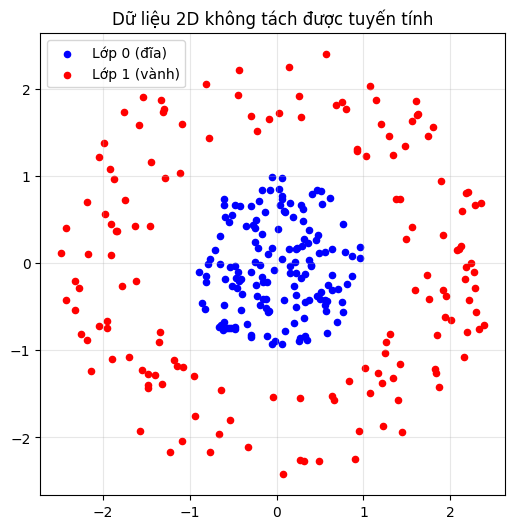

In [24]:
def gen_disk(n, r_max=1.0):
    u = np.random.uniform(0, 1, n)
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = r_max * np.sqrt(u)
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

def gen_ring(n, r_in=1.5, r_out=2.5):
    u = np.random.uniform(0, 1, n)
    theta = np.random.uniform(0, 2 * np.pi, n)
    r = np.sqrt(u * (r_out**2 - r_in**2) + r_in**2)
    return np.column_stack((r * np.cos(theta), r * np.sin(theta)))

n_per_class = 150
X0 = gen_disk(n_per_class)
X1 = gen_ring(n_per_class)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n_per_class), np.ones(n_per_class)])

plt.figure(figsize=(6, 6))
plt.scatter(X0[:, 0], X0[:, 1], color='blue', label='Lớp 0 (đĩa)', s=20)
plt.scatter(X1[:, 0], X1[:, 1], color='red',  label='Lớp 1 (vành)', s=20)
plt.legend(); plt.axis('equal'); plt.grid(alpha=0.3)
plt.title('Dữ liệu 2D không tách được tuyến tính')
plt.show()

In [25]:
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train = torch.FloatTensor(X_train_np)
y_train = torch.FloatTensor(y_train_np).unsqueeze(1)
X_test  = torch.FloatTensor(X_test_np)
y_test  = torch.FloatTensor(y_test_np).unsqueeze(1)

print(f'Train: {len(X_train)} điểm,  Test: {len(X_test)} điểm')

Train: 240 điểm,  Test: 60 điểm


Baseline: Logistic Regression

Trước khi train ANN, ta chạy thử logistic regression — mạng không có tầng ẩn. Vì hai cụm KHÔNG tách được bằng đường thẳng, model này nên đạt accuracy không hơn ~50% nhiều. Đây là baseline để nhìn rõ ANN cải thiện thế nào.

In [26]:
logreg = nn.Sequential(nn.Linear(2, 1), nn.Sigmoid())
opt_lr = optim.Adam(logreg.parameters(), lr=0.05)
for _ in range(300):
    opt_lr.zero_grad()
    loss = nn.BCELoss()(logreg(X_train), y_train)
    loss.backward(); opt_lr.step()

with torch.no_grad():
    pred = (logreg(X_test) > 0.5).float()
    acc_lr = (pred == y_test).float().mean().item()
print(f'Logistic regression accuracy: {acc_lr*100:.2f}%   (kỳ vọng quanh 50%)')

Logistic regression accuracy: 41.67%   (kỳ vọng quanh 50%)


Xây dựng ANN

Kiến trúc: 2 → 4 (ReLU) → 1 (Sigmoid).

In [27]:
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 4)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer2(self.relu(self.layer1(x))))

model = ANN()
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
print(model)

ANN(
  (layer1): Linear(in_features=2, out_features=4, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=4, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Huấn luyện và theo dõi loss / accuracy

Ta sẽ train 500 epoch (đủ để hội tụ trên bài này) và lưu cả train loss + test accuracy qua từng epoch.

Epoch  100/500  loss=0.3699  test_acc=83.33%
Epoch  200/500  loss=0.1062  test_acc=98.33%
Epoch  300/500  loss=0.0415  test_acc=100.00%
Epoch  400/500  loss=0.0222  test_acc=100.00%
Epoch  500/500  loss=0.0143  test_acc=100.00%


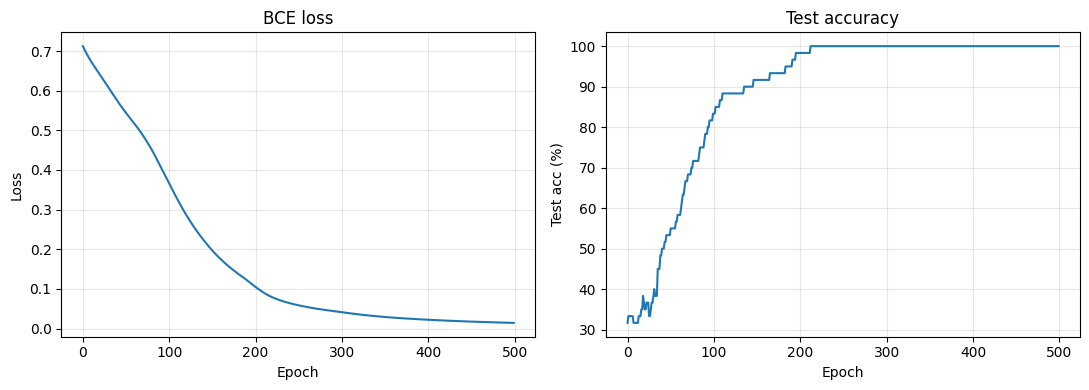

In [28]:
epochs = 500
loss_history, acc_history = [], []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        test_pred = (model(X_test) > 0.5).float()
        acc = (test_pred == y_test).float().mean().item()
    loss_history.append(loss.item())
    acc_history.append(acc)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}/{epochs}  loss={loss.item():.4f}  test_acc={acc*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCE loss')
axes[1].plot([a*100 for a in acc_history]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')
plt.tight_layout(); plt.show()

In [29]:
model.eval()
with torch.no_grad():
    pred = (model(X_test) > 0.5).float()
    acc_ann = (pred == y_test).float().mean().item()
print(f'ANN final test accuracy: {acc_ann*100:.2f}%')
print(f'(Baseline LogReg đạt {acc_lr*100:.2f}% — ANN thắng đậm vì học được ranh giới phi tuyến.)')

ANN final test accuracy: 100.00%
(Baseline LogReg đạt 41.67% — ANN thắng đậm vì học được ranh giới phi tuyến.)


Trực quan ranh giới quyết định

Vẽ contour xác suất (không phải hard 0/1) sẽ cho ta thấy mạng "tự tin" ở vùng nào, "ngập ngừng" ở vùng nào.

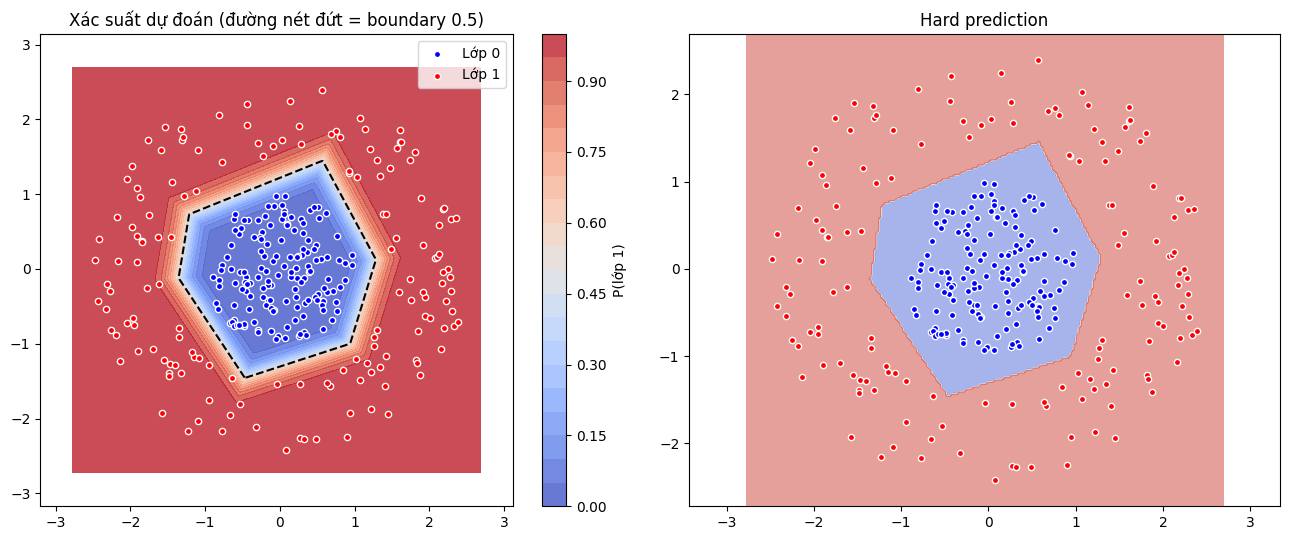

In [30]:
x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

model.eval()
with torch.no_grad():
    proba = model(grid).numpy().reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Bên trái: contour xác suất (mềm)
cs = axes[0].contourf(xx, yy, proba, levels=20, cmap='coolwarm', alpha=0.8)
axes[0].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20, label='Lớp 0')
axes[0].scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20, label='Lớp 1')
axes[0].contour(xx, yy, proba, levels=[0.5], colors='black', linestyles='--')
plt.colorbar(cs, ax=axes[0], label='P(lớp 1)')
axes[0].set_title('Xác suất dự đoán (đường nét đứt = boundary 0.5)')
axes[0].axis('equal'); axes[0].legend()

# Bên phải: hard prediction
axes[1].contourf(xx, yy, (proba > 0.5).astype(int), alpha=0.5, cmap='coolwarm')
axes[1].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20)
axes[1].scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20)
axes[1].set_title('Hard prediction')
axes[1].axis('equal')

plt.tight_layout(); plt.show()

**Tăng số nút ẩn:** đổi lớp ẩn từ 4 nút thành 8 nút. Train 500 epoch. Ghi loss cuối, test accuracy.

In [31]:
class ANN_8nut(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer2(self.relu(self.layer1(x))))

model_8nut = ANN_8nut()
criterion = nn.BCELoss()
optimizer = optim.Adam(model_8nut.parameters(), lr=0.01)
print(model_8nut)

ANN_8nut(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Epoch  100/500  loss=0.1982  test_acc=98.33%
Epoch  200/500  loss=0.0452  test_acc=100.00%
Epoch  300/500  loss=0.0210  test_acc=100.00%
Epoch  400/500  loss=0.0123  test_acc=100.00%
Epoch  500/500  loss=0.0082  test_acc=100.00%


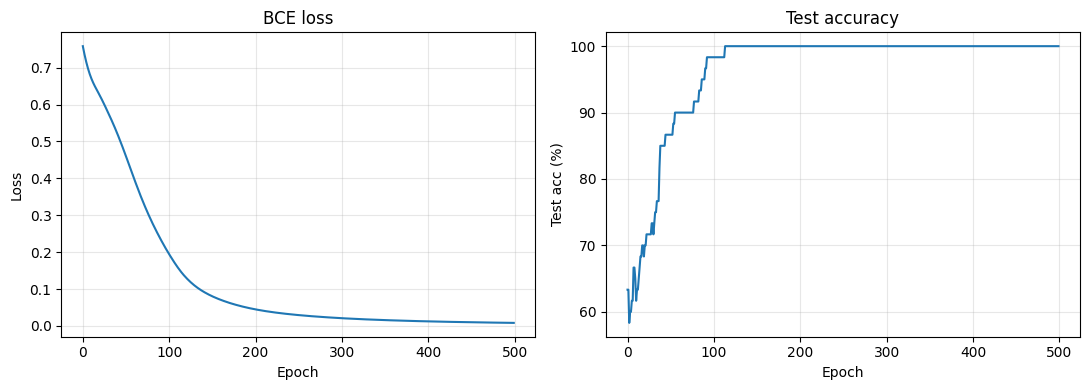

In [32]:
epochs = 500
loss_history, acc_history = [], []

for epoch in range(epochs):
    model_8nut.train()
    optimizer.zero_grad()
    outputs = model_8nut(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    model_8nut.eval()
    with torch.no_grad():
        test_pred = (model_8nut(X_test) > 0.5).float()
        acc = (test_pred == y_test).float().mean().item()
    loss_history.append(loss.item())
    acc_history.append(acc)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}/{epochs}  loss={loss.item():.4f}  test_acc={acc*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCE loss')
axes[1].plot([a*100 for a in acc_history]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')
plt.tight_layout(); plt.show()

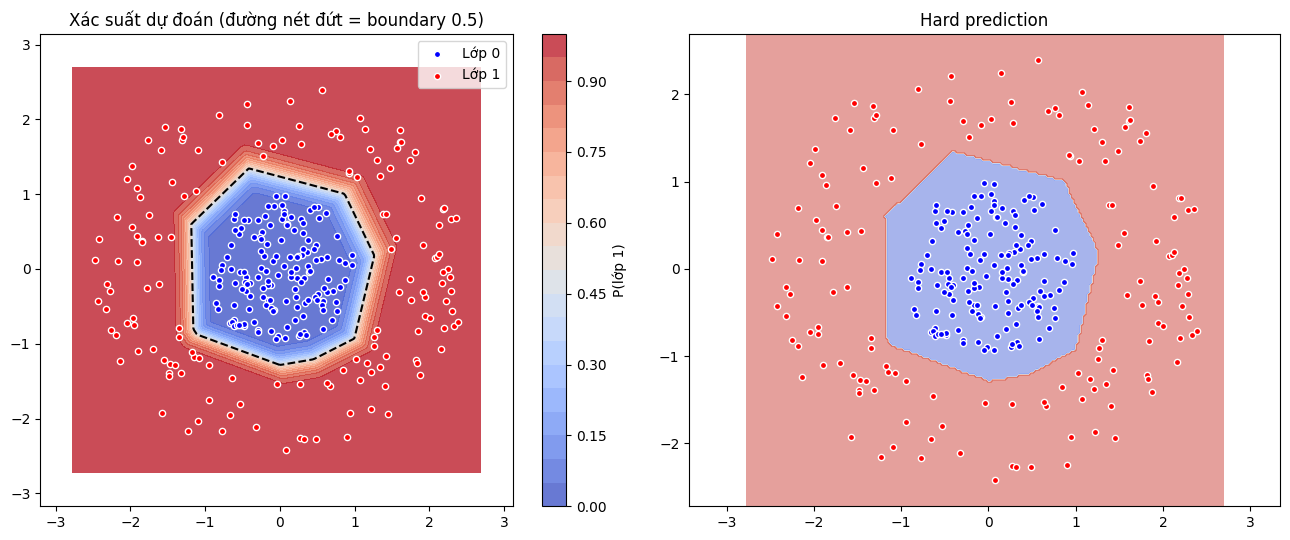

In [36]:
x_min, x_max = X[:, 0].min() - 0.3, X[:, 0].max() + 0.3
y_min, y_max = X[:, 1].min() - 0.3, X[:, 1].max() + 0.3
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])

model_8nut.eval()
with torch.no_grad():
    proba = model_8nut(grid).numpy().reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Bên trái: contour xác suất (mềm)
cs = axes[0].contourf(xx, yy, proba, levels=20, cmap='coolwarm', alpha=0.8)
axes[0].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20, label='Lớp 0')
axes[0].scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20, label='Lớp 1')
axes[0].contour(xx, yy, proba, levels=[0.5], colors='black', linestyles='--')
plt.colorbar(cs, ax=axes[0], label='P(lớp 1)')
axes[0].set_title('Xác suất dự đoán (đường nét đứt = boundary 0.5)')
axes[0].axis('equal'); axes[0].legend()

# Bên phải: hard prediction
axes[1].contourf(xx, yy, (proba > 0.5).astype(int), alpha=0.5, cmap='coolwarm')
axes[1].scatter(X0[:, 0], X0[:, 1], color='blue', edgecolor='white', s=20)
axes[1].scatter(X1[:, 0], X1[:, 1], color='red',  edgecolor='white', s=20)
axes[1].set_title('Hard prediction')
axes[1].axis('equal')

plt.tight_layout(); plt.show()

**Thêm một lớp ẩn:** kiến trúc 2 → 8 (ReLU) → 6 (ReLU) → 1 (Sigmoid). Train 500 epoch.

In [38]:
class ANN_3lop(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 8)
        self.relu   = nn.ReLU()
        self.layer2 = nn.Linear(8, 6)
        self.relu2  = nn.ReLU()
        self.layer3 = nn.Linear(6, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        return self.sigmoid(self.layer3(self.relu2(self.layer2(self.relu(self.layer1(x))))))

ANN_3lop = ANN_3lop()
criterion = nn.BCELoss()
optimizer = optim.Adam(ANN_3lop.parameters(), lr=0.01)
print(ANN_3lop)

ANN_3lop(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=8, out_features=6, bias=True)
  (relu2): ReLU()
  (layer3): Linear(in_features=6, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


Epoch  100/500  loss=0.0255  test_acc=100.00%
Epoch  200/500  loss=0.0038  test_acc=100.00%
Epoch  300/500  loss=0.0016  test_acc=100.00%
Epoch  400/500  loss=0.0009  test_acc=100.00%
Epoch  500/500  loss=0.0006  test_acc=100.00%


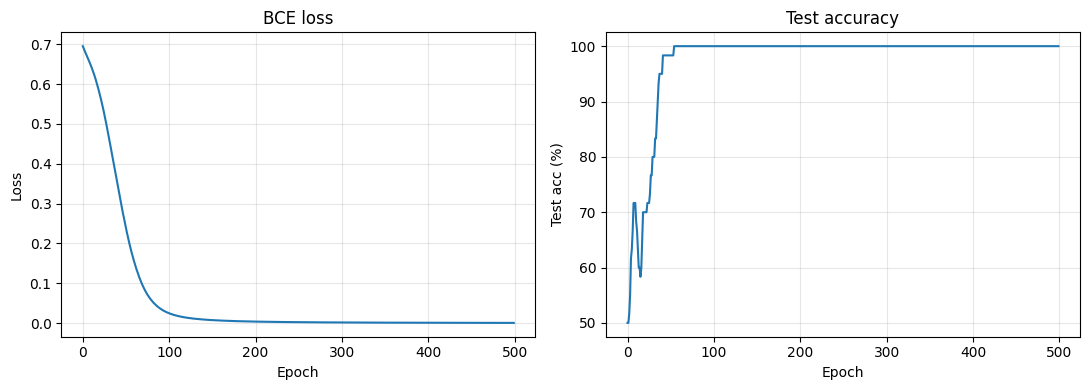

In [39]:
epochs = 500
loss_history, acc_history = [], []

for epoch in range(epochs):
    ANN_3lop.train()
    optimizer.zero_grad()
    outputs = ANN_3lop(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    ANN_3lop.eval()
    with torch.no_grad():
        test_pred = (ANN_3lop(X_test) > 0.5).float()
        acc = (test_pred == y_test).float().mean().item()
    loss_history.append(loss.item())
    acc_history.append(acc)

    if (epoch + 1) % 100 == 0:
        print(f'Epoch {epoch+1:4d}/{epochs}  loss={loss.item():.4f}  test_acc={acc*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(loss_history); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)
axes[0].set_title('BCE loss')
axes[1].plot([a*100 for a in acc_history]); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test acc (%)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Test accuracy')
plt.tight_layout(); plt.show()